In [1]:
import re
from collections import Counter
import nltk
nltk.download('punkt')
from nltk.tokenize import word_tokenize
import matplotlib.pyplot as plt


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Ulan\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [2]:
# Load text
with open("Pride_and_prejudice.txt", "r", encoding="utf8") as f:
    text = f.read()

# Lowercase
text = text.lower()

# Remove Project Gutenberg header/footer
start = text.find("it is a truth universally acknowledged")
end = text.find("end of the project gutenberg ebook")

text = text[start:end]


In [3]:

from nltk.tokenize.punkt import PunktSentenceTokenizer
from nltk.tokenize import TreebankWordTokenizer

# Initialize tokenizers
sentence_tokenizer = PunktSentenceTokenizer()
word_tokenizer = TreebankWordTokenizer()

sentences = sentence_tokenizer.tokenize(text)

tokenized_sentences = []
for s in sentences:
    tokens = word_tokenizer.tokenize(s)
    tokens = [re.sub(r"[^a-z]", "", w.lower()) for w in tokens]
    tokens = [w for w in tokens if w != ""]
    tokenized_sentences.append(tokens)

print("Number of sentences:", len(tokenized_sentences))
print("Example sentence:", tokenized_sentences[0][:15])


Number of sentences: 6959
Example sentence: ['it', 'is', 'a', 'truth', 'universally', 'acknowledged', 'that', 'a', 'single', 'man', 'in', 'possession', 'of', 'a', 'good']


In [4]:
processed_sentences = []

for s in tokenized_sentences:
    processed_sentences.append(["<bos>"] + s + ["<eos>"])


In [5]:
all_tokens = [token for s in processed_sentences for token in s]

token_counts = Counter(all_tokens)

# Optional cutoff
min_freq = 2
vocab = {word for word, freq in token_counts.items() if freq >= min_freq}
vocab.update(["<unk>", "<bos>", "<eos>"])

print("Vocabulary size:", len(vocab))


Vocabulary size: 3948


In [6]:
final_sentences = []

for s in processed_sentences:
    final_sentences.append([w if w in vocab else "<unk>" for w in s])


In [7]:
import random

random.seed(42)
random.shuffle(final_sentences)

n = len(final_sentences)
train = final_sentences[:int(0.8 * n)]
val   = final_sentences[int(0.8 * n):int(0.9 * n)]
test  = final_sentences[int(0.9 * n):]

len(train), len(val), len(test)


(5567, 696, 696)

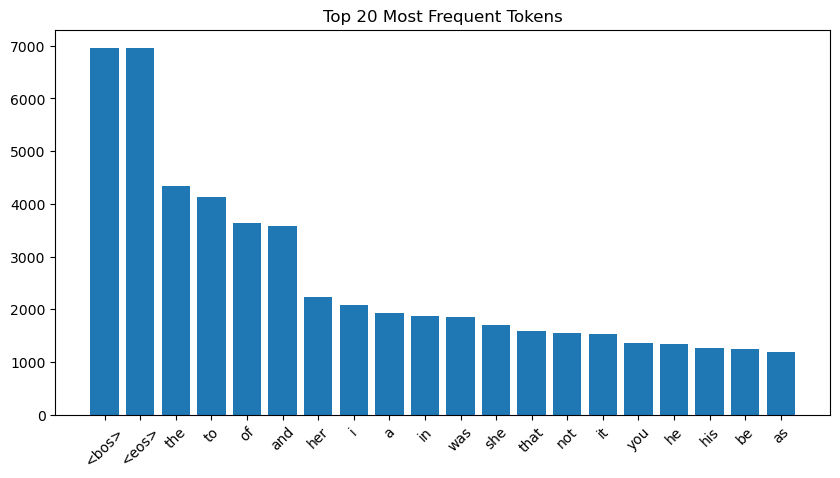

In [8]:
top_tokens = token_counts.most_common(20)
words, freqs = zip(*top_tokens)

plt.figure(figsize=(10,5))
plt.bar(words, freqs)
plt.xticks(rotation=45)
plt.title("Top 20 Most Frequent Tokens")
plt.show()


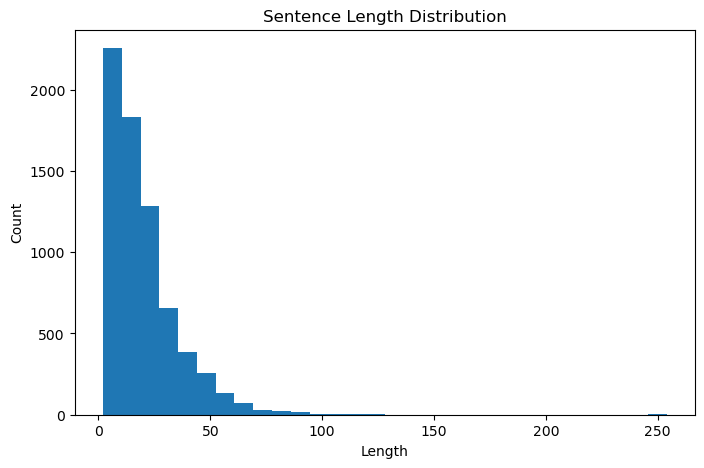

In [9]:
lengths = [len(s) for s in final_sentences]

plt.figure(figsize=(8,5))
plt.hist(lengths, bins=30)
plt.title("Sentence Length Distribution")
plt.xlabel("Length")
plt.ylabel("Count")
plt.show()


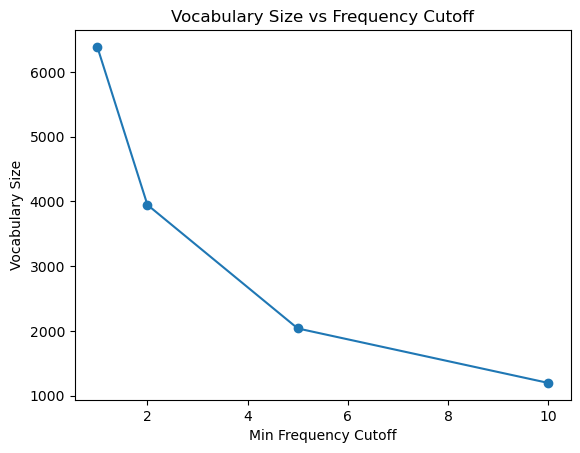

In [10]:
cutoffs = [1, 2, 5, 10]
vocab_sizes = []

for c in cutoffs:
    vocab_sizes.append(sum(1 for w, f in token_counts.items() if f >= c))

plt.plot(cutoffs, vocab_sizes, marker="o")
plt.xlabel("Min Frequency Cutoff")
plt.ylabel("Vocabulary Size")
plt.title("Vocabulary Size vs Frequency Cutoff")
plt.show()


In [11]:
import pickle

with open("data_splits.pkl", "wb") as f:
    pickle.dump((train, val, test, vocab), f)
